# Week 3 Tutorial — Model Evaluation + Stats II

Every concept practiced here was covered in `study-guide.md` first.

**Parts:**
1. Knowledge gap fill-ins — StandardScaler, correlation, kurtosis, log transform
2. Why accuracy fails — the imbalanced data problem
3. The confusion matrix — by hand, then with sklearn
4. Precision, Recall, F1 — compute and interpret
5. ROC curve and AUC
6. Cross-validation
7. YOUR TURN — full evaluation on a new dataset

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

%matplotlib inline
pd.set_option('display.max_columns', None)
np.random.seed(42)
print('Setup complete.')

Setup complete.


---
## Part 1 — Knowledge Gap Fill-ins

Four concepts from week 2 that needed more depth. Work through these before the new material.

### 1.1 — StandardScaler: What It Actually Computes

In [2]:
# Problem: features on very different scales
# Age: 20-80, Salary: 30000-200000
# Without scaling, salary dominates every calculation just because of its size

raw_data = pd.DataFrame({
    'age':    [22, 35, 58, 41, 29],
    'salary': [45000, 72000, 110000, 88000, 51000]
})

print('Raw data:')
print(raw_data)
print()
print('Salary is ~2000x larger than age numerically.')
print('A model treating these as equal would overweight salary massively.')

Raw data:
   age  salary
0   22   45000
1   35   72000
2   58  110000
3   41   88000
4   29   51000

Salary is ~2000x larger than age numerically.
A model treating these as equal would overweight salary massively.


In [3]:
# StandardScaler formula: scaled = (value - mean) / std
# Let's apply it manually to BOTH columns so you see the actual point of scaling

for col in ['age', 'salary']:
    values = raw_data[col]
    mean = values.mean()
    std  = values.std()
    scaled = (values - mean) / std
    print(f'{col} — mean: {mean:.1f}, std: {std:.1f}')
    print(f'  Original: {values.values}')
    print(f'  Scaled:   {scaled.round(2).values}')
    print()

print('Now both features live on the same scale (roughly -2 to +2).')
print('A value of +1.0 means "1 std above average" for BOTH age and salary.')
print('The model can now compare them fairly — neither dominates just because of its unit size.')

age — mean: 37.0, std: 13.7
  Original: [22 35 58 41 29]
  Scaled:   [-1.1  -0.15  1.53  0.29 -0.58]

salary — mean: 73200.0, std: 26752.6
  Original: [ 45000  72000 110000  88000  51000]
  Scaled:   [-1.05 -0.04  1.38  0.55 -0.83]

Now both features live on the same scale (roughly -2 to +2).
A value of +1.0 means "1 std above average" for BOTH age and salary.
The model can now compare them fairly — neither dominates just because of its unit size.


In [4]:
# Now do the same with sklearn StandardScaler on both columns — result should match
scaler = StandardScaler()
scaled_sklearn = scaler.fit_transform(raw_data)  # scale both age and salary

print('Sklearn scaled output (age, salary):')
print(scaled_sklearn.round(2))
print()
print('Compare to manual above — same numbers.')
print('Age and salary are now on equal footing regardless of their original units.')

Sklearn scaled output (age, salary):
[[-1.22 -1.18]
 [-0.16 -0.05]
 [ 1.71  1.54]
 [ 0.33  0.62]
 [-0.65 -0.93]]

Compare to manual above — same numbers.
Age and salary are now on equal footing regardless of their original units.


In [5]:
# CRITICAL: fit on train only, transform both train and test
# This is data leakage if done wrong

X = raw_data.values  # use both columns
# Pretend we have a train/test split
X_train = X[:4]
X_test  = X[4:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # ✅ learns mean/std here
X_test_scaled  = scaler.transform(X_test)        # ✅ uses same mean/std, does NOT relearn

print('Train scaled:')
print(X_train_scaled.round(2))
print()
print('Test scaled (using training mean/std):')
print(X_test_scaled.round(2))
print()
print('The scaler learned mean/std from TRAINING data only.')
print('Test data is scaled using those same values — not its own.')

Train scaled:
[[-1.31 -1.42]
 [-0.31 -0.28]
 [ 1.47  1.32]
 [ 0.15  0.39]]

Test scaled (using training mean/std):
[[-0.77 -1.17]]

The scaler learned mean/std from TRAINING data only.
Test data is scaled using those same values — not its own.


**Why does fit on train only matter?**

In a real deployment, you train your model once, then use it on new data for months or years. That future data doesn't exist yet when you train. So your scaler must use only what was known during training — the training data's mean and std. Using test data to fit the scaler would be "peeking at the future."

### 1.2 — Correlation Interpretation: Weak vs Strong

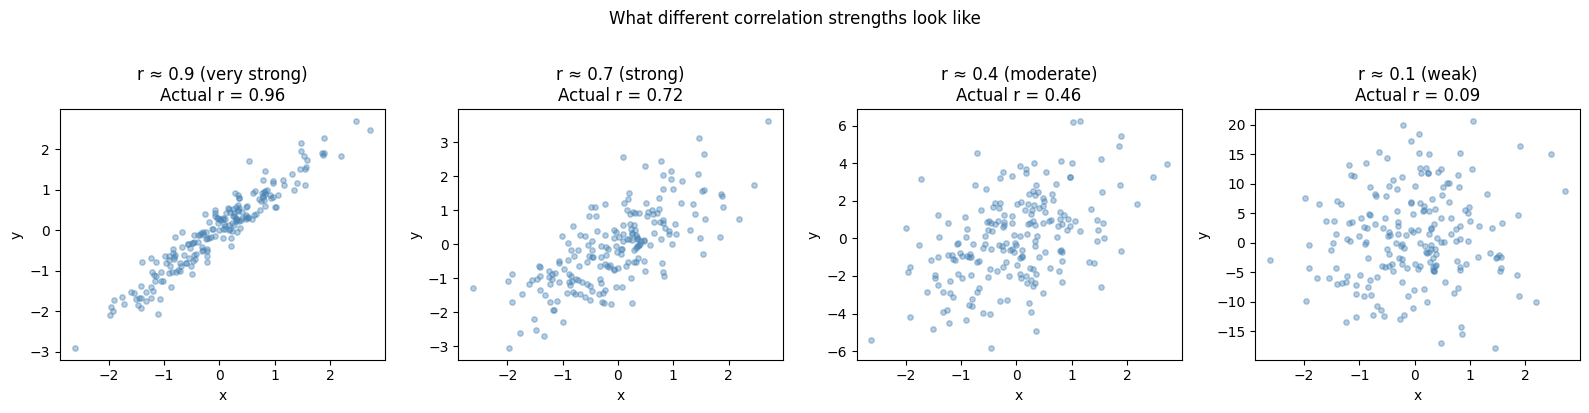

In [6]:
# Let's generate data with known correlation strengths and see what they look like visually
# This builds your intuition for interpreting correlation numbers

n = 200
x = np.random.randn(n)

def make_correlated(x, strength, noise_scale):
    """Create y that has a specific correlation with x."""
    noise = np.random.randn(len(x)) * noise_scale
    return strength * x + noise

correlations = {
    'r ≈ 0.9 (very strong)': make_correlated(x, 1.0, 0.3),
    'r ≈ 0.7 (strong)':      make_correlated(x, 1.0, 0.8),
    'r ≈ 0.4 (moderate)':    make_correlated(x, 1.0, 2.0),
    'r ≈ 0.1 (weak)':        make_correlated(x, 1.0, 8.0),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, y) in zip(axes, correlations.items()):
    r = np.corrcoef(x, y)[0, 1]  # actual computed correlation
    ax.scatter(x, y, alpha=0.4, s=15, color='steelblue')
    ax.set_title(f'{label}\nActual r = {r:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('What different correlation strengths look like', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Recall from Titanic week 2 — let's re-label those numbers with our new thresholds
titanic_correlations = {
    'pclass vs survived': -0.338,
    'fare vs survived':    0.257,
    'pclass vs fare':     -0.549,
    'sibsp vs parch':      0.415,
    'age vs survived':    -0.065,
}

def interpret_correlation(r):
    abs_r = abs(r)
    if abs_r < 0.10:   return 'negligible'
    elif abs_r < 0.30: return 'weak'
    elif abs_r < 0.50: return 'moderate'
    elif abs_r < 0.70: return 'strong'
    elif abs_r < 0.90: return 'very strong'
    else:              return 'near perfect'

print('Titanic correlation re-interpreted:')
print(f'{"Feature pair":<25} {"r":>6}  Strength')
print('-' * 50)
for pair, r in titanic_correlations.items():
    print(f'{pair:<25} {r:>6.3f}  {interpret_correlation(r)}')

Titanic correlation re-interpreted:
Feature pair                   r  Strength
--------------------------------------------------
pclass vs survived        -0.338  moderate
fare vs survived           0.257  weak
pclass vs fare            -0.549  strong
sibsp vs parch             0.415  moderate
age vs survived           -0.065  negligible


### 1.3 — Kurtosis: Reading the Tails

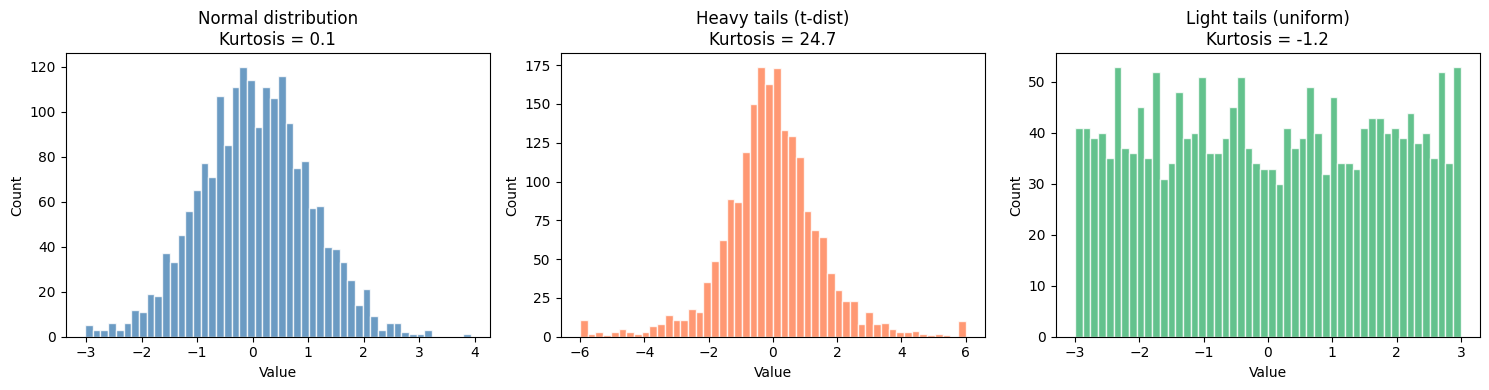

Normal:     kurtosis ≈ 0   → baseline
Heavy tail: kurtosis > 0   → more extreme outliers than normal
Light tail: kurtosis < 0   → fewer extremes, flatter shape


In [8]:
# Generate three distributions with different kurtosis and plot them side by side
# This shows you what high/low kurtosis actually looks like

normal_data   = np.random.normal(0, 1, 2000)           # kurtosis ≈ 0
heavy_tail    = np.random.standard_t(df=3, size=2000)  # kurtosis > 0 (heavy tails)
light_tail    = np.random.uniform(-3, 3, 2000)         # kurtosis < 0 (light tails)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (normal_data, 'Normal distribution',    'steelblue'),
    (heavy_tail,  'Heavy tails (t-dist)',   'coral'),
    (light_tail,  'Light tails (uniform)',  'mediumseagreen'),
]

for ax, (data, title, color) in zip(axes, datasets):
    # Clip for display — heavy tails can have extreme outliers
    clipped = np.clip(data, -6, 6)
    ax.hist(clipped, bins=50, color=color, edgecolor='white', alpha=0.8)
    kurtosis = pd.Series(data).kurtosis()
    ax.set_title(f'{title}\nKurtosis = {kurtosis:.1f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Normal:     kurtosis ≈ 0   → baseline')
print('Heavy tail: kurtosis > 0   → more extreme outliers than normal')
print('Light tail: kurtosis < 0   → fewer extremes, flatter shape')

In [9]:
# Check kurtosis on real data
df = sns.load_dataset('titanic')

print('Kurtosis of Titanic numeric columns:')
for col in ['age', 'fare', 'sibsp', 'parch']:
    k = df[col].dropna().kurtosis()
    if abs(k) < 1:
        note = '→ normal-like, no action needed'
    elif k > 3:
        note = '→ heavy tails, consider log transform'
    elif k > 10:
        note = '→ extreme outliers, investigate'
    else:
        note = '→ mild deviation from normal'
    print(f'  {col:<8}: {k:>6.1f}  {note}')

Kurtosis of Titanic numeric columns:
  age     :    0.2  → normal-like, no action needed
  fare    :   33.4  → heavy tails, consider log transform
  sibsp   :   17.9  → heavy tails, consider log transform
  parch   :    9.8  → heavy tails, consider log transform


### 1.4 — Log Transform: Why and When

In [10]:
# First, understand what log does to numbers
# It compresses large values and spreads out small ones

values = [1, 10, 100, 1000, 10000]

print('What log does to numbers:')
print(f'{"Original":>10}  {"log(x)":>8}  {"log1p(x)":>10}')
print('-' * 35)
for v in values:
    print(f'{v:>10}  {np.log(v):>8.2f}  {np.log1p(v):>10.2f}')

print()
print('A 10x increase in original → only ~2.3 increase in log.')
print('A 1000x increase → only ~6.9 increase in log.')
print('This is what compresses the long right tail.')

What log does to numbers:
  Original    log(x)    log1p(x)
-----------------------------------
         1      0.00        0.69
        10      2.30        2.40
       100      4.61        4.62
      1000      6.91        6.91
     10000      9.21        9.21

A 10x increase in original → only ~2.3 increase in log.
A 1000x increase → only ~6.9 increase in log.
This is what compresses the long right tail.


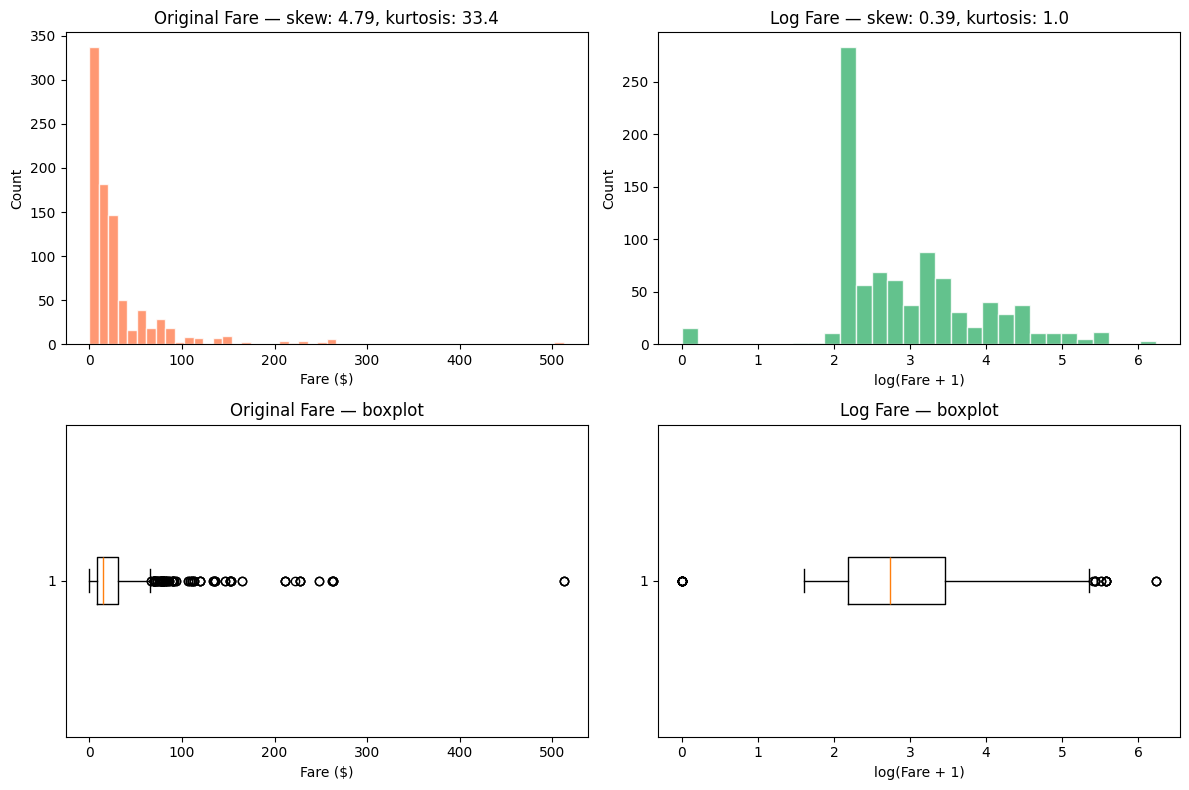

After log transform:
  Skewness dropped from 4.8 to 0.39
  Kurtosis dropped from 33.4 to 1.0
  Distribution is much closer to normal — linear models will perform better


In [11]:
# Apply to Titanic fare and compare
fare = df['fare'].dropna()
fare_log = np.log1p(fare)   # log1p = log(1 + x), handles fare=0

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original histogram
axes[0,0].hist(fare, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0,0].set_title(f'Original Fare — skew: {fare.skew():.2f}, kurtosis: {fare.kurtosis():.1f}')
axes[0,0].set_xlabel('Fare ($)')
axes[0,0].set_ylabel('Count')

# Log transformed histogram
axes[0,1].hist(fare_log, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[0,1].set_title(f'Log Fare — skew: {fare_log.skew():.2f}, kurtosis: {fare_log.kurtosis():.1f}')
axes[0,1].set_xlabel('log(Fare + 1)')
axes[0,1].set_ylabel('Count')

# Original boxplot
axes[1,0].boxplot(fare, vert=False)
axes[1,0].set_title('Original Fare — boxplot')
axes[1,0].set_xlabel('Fare ($)')

# Log boxplot
axes[1,1].boxplot(fare_log, vert=False)
axes[1,1].set_title('Log Fare — boxplot')
axes[1,1].set_xlabel('log(Fare + 1)')

plt.tight_layout()
plt.show()

print('After log transform:')
print(f'  Skewness dropped from {fare.skew():.1f} to {fare_log.skew():.2f}')
print(f'  Kurtosis dropped from {fare.kurtosis():.1f} to {fare_log.kurtosis():.1f}')
print('  Distribution is much closer to normal — linear models will perform better')

**YOUR TURN 1.4:**

In [ ]:
# Q: The 'sibsp' column (number of siblings/spouses aboard) has kurtosis > 3.
# 1. Print its skewness and kurtosis
# 2. Apply a log transform
# 3. Print skewness and kurtosis after
# 4. Is the transform worth it? Write your reasoning as a comment.

# YOUR CODE HERE
df_sibp = df['sibsp'].dropna()
print(f'Skew: {df_sibp.skew():.3}')
print(f'Kurtosis: {df_sibp.kurtosis():.3}')
df_sibp_log = np.log1p(df_sibp)
print(f'Skew after log transform: {df_sibp_log.skew():.3}')
print(f'Kurtosis after log transform: {df_sibp_log.kurtosis():.3}')

# Kurtosis dropped significantly to less than 3 so outliers aren't as influential
# but it is still highly skewed meaning normal distrubuition will not work as well still

Skew: 3.7
Kurtosis: 17.9
Skew after log transform: 1.66
Kurtosis after log transform: 2.47


---
## Part 2 — Why Accuracy Fails

Before you can understand better metrics, you need to feel the problem with accuracy.

In [20]:
# Simulate a disease detection scenario
# 1000 patients, disease affects only 1%
np.random.seed(42)
n_patients = 1000
n_sick     = 10   # 1% have the disease

# True labels: 0=healthy, 1=sick
y_true = np.array([1]*n_sick + [0]*(n_patients - n_sick))

print(f'Total patients: {n_patients}')
print(f'Sick:           {n_sick} ({n_sick/n_patients:.1%})')
print(f'Healthy:        {n_patients - n_sick} ({(n_patients-n_sick)/n_patients:.1%})')

Total patients: 1000
Sick:           10 (1.0%)
Healthy:        990 (99.0%)


In [21]:
# "Lazy" model: always predicts healthy (0)
# This requires zero intelligence — just say no every time
y_pred_lazy = np.zeros(n_patients, dtype=int)

lazy_accuracy = accuracy_score(y_true, y_pred_lazy)
print(f'Lazy model accuracy: {lazy_accuracy:.1%}')
print()
print('99% accuracy — but this model never detects a single sick patient.')
print('In a medical context, this model would be dangerous.')
print()
print('This is why accuracy alone is not enough.')

Lazy model accuracy: 99.0%

99% accuracy — but this model never detects a single sick patient.
In a medical context, this model would be dangerous.

This is why accuracy alone is not enough.


In [22]:
# A smarter model — random predictions with some signal
# Still imperfect but actually tries
y_pred_smart = np.array([1 if (truth == 1 and np.random.rand() > 0.2) or 
                              (truth == 0 and np.random.rand() > 0.95) 
                         else 0 
                         for truth in y_true])

smart_accuracy = accuracy_score(y_true, y_pred_smart)
print(f'Smart model accuracy: {smart_accuracy:.1%}')
print(f'Lazy model accuracy:  {lazy_accuracy:.1%}')
print()
print('The smart model has LOWER accuracy than the lazy model.')
print('But which would you trust with your health?')
print('We need metrics that capture this — that is what precision and recall do.')

Smart model accuracy: 95.2%
Lazy model accuracy:  99.0%

The smart model has LOWER accuracy than the lazy model.
But which would you trust with your health?
We need metrics that capture this — that is what precision and recall do.


---
## Part 3 — The Confusion Matrix

Everything in classification evaluation comes from 4 numbers: TP, TN, FP, FN.
Learn to read the confusion matrix cold — it's on every ML job interview.

In [23]:
# Manually label the confusion matrix cells for the disease example
# sklearn's confusion_matrix returns: [[TN, FP], [FN, TP]]

cm = confusion_matrix(y_true, y_pred_smart)
TN, FP, FN, TP = cm.ravel()

print('Confusion matrix (raw numbers):')
print(cm)
print()
print(f'TN (True Negative):  {TN}  — correctly predicted healthy')
print(f'FP (False Positive): {FP}  — predicted sick, actually healthy (false alarm)')
print(f'FN (False Negative): {FN}   — predicted healthy, actually sick (missed case)')
print(f'TP (True Positive):  {TP}   — correctly predicted sick')

Confusion matrix (raw numbers):
[[945  45]
 [  3   7]]

TN (True Negative):  945  — correctly predicted healthy
FP (False Positive): 45  — predicted sick, actually healthy (false alarm)
FN (False Negative): 3   — predicted healthy, actually sick (missed case)
TP (True Positive):  7   — correctly predicted sick


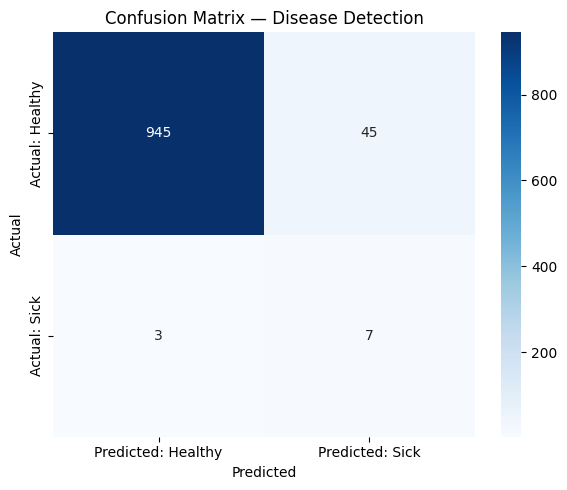

Diagonal (top-left, bottom-right) = correct predictions
Off-diagonal = errors

Top-left (TN=945):  model correctly said healthy — good
Top-right (FP=45): model said sick but patient healthy — false alarm
Bot-left (FN=3):  model missed a sick patient — dangerous miss
Bot-right (TP=7):  model correctly identified sick — what we want


In [24]:
# Visualize it as a heatmap — much easier to read
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: Healthy', 'Predicted: Sick'],
    yticklabels=['Actual: Healthy',    'Actual: Sick']
)
ax.set_title('Confusion Matrix — Disease Detection')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print('Diagonal (top-left, bottom-right) = correct predictions')
print('Off-diagonal = errors')
print()
print(f'Top-left (TN={TN}):  model correctly said healthy — good')
print(f'Top-right (FP={FP}): model said sick but patient healthy — false alarm')
print(f'Bot-left (FN={FN}):  model missed a sick patient — dangerous miss')
print(f'Bot-right (TP={TP}):  model correctly identified sick — what we want')

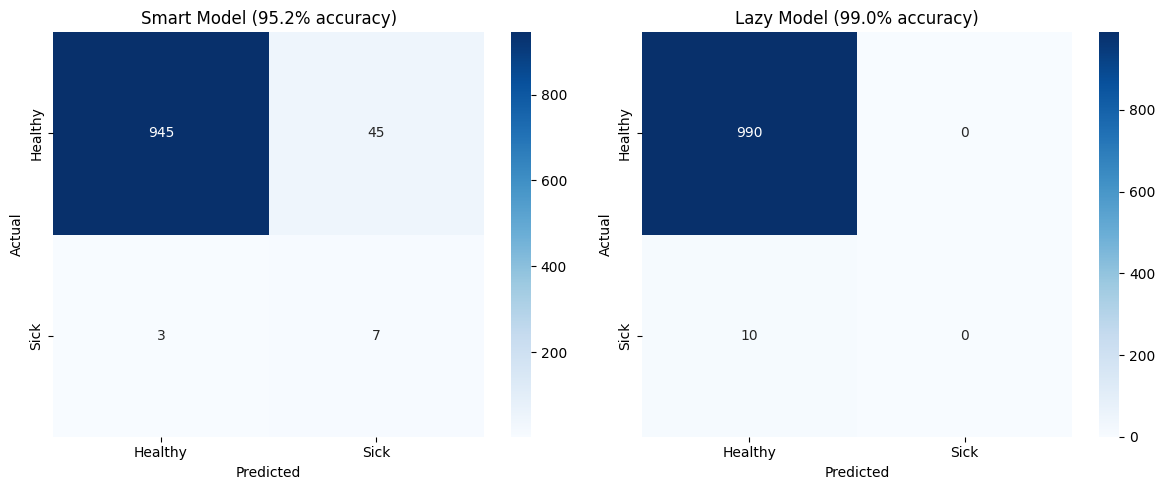

Lazy model: bottom-left cell = 10 (missed ALL sick patients)
Smart model: actually catches some — even though accuracy is lower


In [25]:
# Compare lazy model's confusion matrix
cm_lazy = confusion_matrix(y_true, y_pred_lazy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (matrix, title) in zip(axes, [
    (cm,      f'Smart Model ({smart_accuracy:.1%} accuracy)'),
    (cm_lazy, f'Lazy Model ({lazy_accuracy:.1%} accuracy)')
]):
    sns.heatmap(
        matrix, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Healthy', 'Sick'],
        yticklabels=['Healthy', 'Sick'],
        ax=ax
    )
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print('Lazy model: bottom-left cell = 10 (missed ALL sick patients)')
print('Smart model: actually catches some — even though accuracy is lower')

---
## Part 4 — Precision, Recall, and F1

Now we compute the metrics that actually tell the full story.

In [26]:
# Compute by hand from TP, FP, FN — so you know what sklearn is calculating

precision_manual = TP / (TP + FP)
recall_manual    = TP / (TP + FN)
f1_manual        = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print('=== Computed by hand ===')
print(f'Precision = TP / (TP + FP) = {TP} / ({TP} + {FP}) = {precision_manual:.3f}')
print(f'Recall    = TP / (TP + FN) = {TP} / ({TP} + {FN}) = {recall_manual:.3f}')
print(f'F1        = 2 × P × R / (P + R)                  = {f1_manual:.3f}')

=== Computed by hand ===
Precision = TP / (TP + FP) = 7 / (7 + 45) = 0.135
Recall    = TP / (TP + FN) = 7 / (7 + 3) = 0.700
F1        = 2 × P × R / (P + R)                  = 0.226


In [27]:
# Verify with sklearn
precision_sk = precision_score(y_true, y_pred_smart)
recall_sk    = recall_score(y_true, y_pred_smart)
f1_sk        = f1_score(y_true, y_pred_smart)

print('=== Sklearn output ===')
print(f'Precision: {precision_sk:.3f}')
print(f'Recall:    {recall_sk:.3f}')
print(f'F1:        {f1_sk:.3f}')
print()
print('Same numbers — sklearn just automates the formula.')

=== Sklearn output ===
Precision: 0.135
Recall:    0.700
F1:        0.226

Same numbers — sklearn just automates the formula.


In [28]:
# classification_report gives all metrics at once, per class
# This is what you'll use day-to-day
print(classification_report(y_true, y_pred_smart, target_names=['Healthy', 'Sick']))
print()
print('How to read this report:')
print('  precision: of all predicted Sick, how many were actually Sick?')
print('  recall:    of all actually Sick, how many did we catch?')
print('  f1-score:  harmonic mean of precision and recall')
print('  support:   how many samples of that class exist in the data')

              precision    recall  f1-score   support

     Healthy       1.00      0.95      0.98       990
        Sick       0.13      0.70      0.23        10

    accuracy                           0.95      1000
   macro avg       0.57      0.83      0.60      1000
weighted avg       0.99      0.95      0.97      1000


How to read this report:
  precision: of all predicted Sick, how many were actually Sick?
  recall:    of all actually Sick, how many did we catch?
  f1-score:  harmonic mean of precision and recall
  support:   how many samples of that class exist in the data


In [29]:
# The precision-recall tradeoff in action
# Changing the threshold shifts the balance between precision and recall

# First we need probability scores — not just 0/1 predictions
# Simulate probabilities for the smart model
np.random.seed(42)
probs_sick = np.where(
    y_true == 1,
    np.random.beta(5, 2, n_patients),   # sick patients → higher probability scores
    np.random.beta(1, 5, n_patients)    # healthy patients → lower probability scores
)

thresholds = [0.2, 0.3, 0.5, 0.7, 0.8]

print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>6}')
print('-' * 40)
for t in thresholds:
    y_pred_t = (probs_sick >= t).astype(int)
    p = precision_score(y_true, y_pred_t, zero_division=0)
    r = recall_score(y_true, y_pred_t, zero_division=0)
    f = f1_score(y_true, y_pred_t, zero_division=0)
    print(f'{t:>10.1f} {p:>10.3f} {r:>8.3f} {f:>6.3f}')

print()
print('Lower threshold → higher recall, lower precision (catches more, more false alarms)')
print('Higher threshold → higher precision, lower recall (more selective, misses more)')

 Threshold  Precision   Recall     F1
----------------------------------------
       0.2      0.032    1.000  0.062
       0.3      0.056    1.000  0.105
       0.5      0.263    1.000  0.417
       0.7      0.636    0.700  0.667
       0.8      0.750    0.300  0.429

Lower threshold → higher recall, lower precision (catches more, more false alarms)
Higher threshold → higher precision, lower recall (more selective, misses more)


---
## Part 5 — ROC Curve and AUC

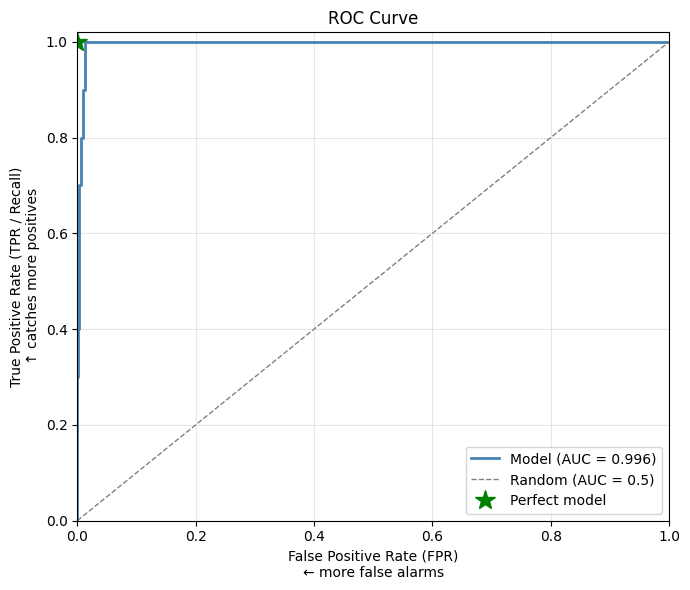

AUC = 0.996

How to read this:
  - Each point on the curve = one threshold setting
  - Top-left corner = perfect (high recall, low false alarm rate)
  - Diagonal = random guessing (useless model)
  - AUC 1.00 means: given a random sick and healthy patient,
    the model ranks the sick one higher 100% of the time


In [30]:
# ROC curve: plots TPR (recall) vs FPR at every possible threshold
# sklearn.metrics.roc_curve does this automatically

fpr, tpr, thresholds_roc = roc_curve(y_true, probs_sick)
auc = roc_auc_score(y_true, probs_sick)

fig, ax = plt.subplots(figsize=(7, 6))

# Our model's ROC curve
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Model (AUC = {auc:.3f})')

# Random baseline — diagonal line (AUC = 0.5)
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')

# Perfect model point — top-left corner
ax.plot(0, 1, 'g*', markersize=15, label='Perfect model')

ax.set_xlabel('False Positive Rate (FPR)\n← more false alarms')
ax.set_ylabel('True Positive Rate (TPR / Recall)\n↑ catches more positives')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.3f}')
print()
print('How to read this:')
print('  - Each point on the curve = one threshold setting')
print('  - Top-left corner = perfect (high recall, low false alarm rate)')
print('  - Diagonal = random guessing (useless model)')
print(f'  - AUC {auc:.2f} means: given a random sick and healthy patient,')
print(f'    the model ranks the sick one higher {auc:.0%} of the time')

---
## Part 6 — Cross-Validation

A single train/test split gives you one score. Cross-validation gives you a distribution of scores — much more reliable.

In [31]:
# Load breast cancer dataset — real binary classification problem
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Classes: {cancer.target_names}')  # malignant=0, benign=1
print(f'Class distribution: {np.bincount(y)}')

Dataset: 569 samples, 30 features
Classes: ['malignant' 'benign']
Class distribution: [212 357]


In [32]:
# Single train/test split — do this 5 times with different random states
# Watch how much the score varies

model = LogisticRegression(max_iter=5000)
scaler = StandardScaler()

print('Single split scores (5 different random splits):')
single_scores = []
for seed in [0, 1, 2, 3, 4]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    model.fit(X_train_s, y_train)
    score = f1_score(y_test, model.predict(X_test_s))
    single_scores.append(score)
    print(f'  Seed {seed}: F1 = {score:.4f}')

print(f'\nRange: {min(single_scores):.4f} – {max(single_scores):.4f}')
print(f'This {max(single_scores)-min(single_scores):.4f} spread is just from different splits — not model changes.')

Single split scores (5 different random splits):
  Seed 0: F1 = 0.9701
  Seed 1: F1 = 0.9793
  Seed 2: F1 = 0.9781
  Seed 3: F1 = 0.9799
  Seed 4: F1 = 0.9744

Range: 0.9701 – 0.9799
This 0.0097 spread is just from different splits — not model changes.


In [33]:
# Cross-validation — a more reliable estimate
# Pipeline: scale then classify (important — scaler must be inside the CV loop)
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=5000))
])

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

print('5-fold cross-validation F1 scores:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')

print(f'\nMean F1: {cv_scores.mean():.4f}')
print(f'Std:     {cv_scores.std():.4f}  ← how consistent the model is across folds')
print()
print('Report model performance as: mean ± std')
print(f'This model: F1 = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

5-fold cross-validation F1 scores:
  Fold 1: 0.9859
  Fold 2: 0.9861
  Fold 3: 0.9796
  Fold 4: 0.9793
  Fold 5: 0.9929

Mean F1: 0.9848
Std:     0.0050  ← how consistent the model is across folds

Report model performance as: mean ± std
This model: F1 = 0.985 ± 0.005


In [34]:
# Why Pipeline? — it ensures scaling happens inside each fold
# Without pipeline:
#   scaler fits on ALL data → test data leaks into scaler → inflated scores
# With pipeline:
#   scaler fits only on training portion of each fold → honest evaluation

print('Pipeline ensures no data leakage during cross-validation.')
print('Each fold: scaler fits on train portion, transforms test portion separately.')
print()
print('Always wrap your scaler + model into a Pipeline before cross-validating.')

Pipeline ensures no data leakage during cross-validation.
Each fold: scaler fits on train portion, transforms test portion separately.

Always wrap your scaler + model into a Pipeline before cross-validating.


---
## Part 7 — YOUR TURN: Full Evaluation on a Real Dataset

Put everything together. You will:
1. Load the breast cancer dataset
2. Train a Logistic Regression model
3. Evaluate it properly using all metrics from this week

Work through each cell. The code structure is given — fill in the blanks.

In [ ]:
# Step 1: Split and scale
# Use train_test_split with test_size=0.2, random_state=42, stratify=y
# Scale using StandardScaler (fit on train, transform both)

# YOUR CODE HERE
sc = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_s, X_test_s = sc.fit_transform(X_train), sc.transform(X_test)

In [39]:
# Step 2: Train a LogisticRegression (max_iter=5000)

# YOUR CODE HERE
model = LogisticRegression(max_iter=5000)
model.fit(X_train_s, y_train)


LogisticRegression(max_iter=5000)

In [48]:
# Step 3: Print accuracy, then classification report
# After seeing the report, answer: is accuracy a fair summary of this model?

# YOUR CODE HERE
y_predict = model.predict(X_test_s)
accuracy = accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



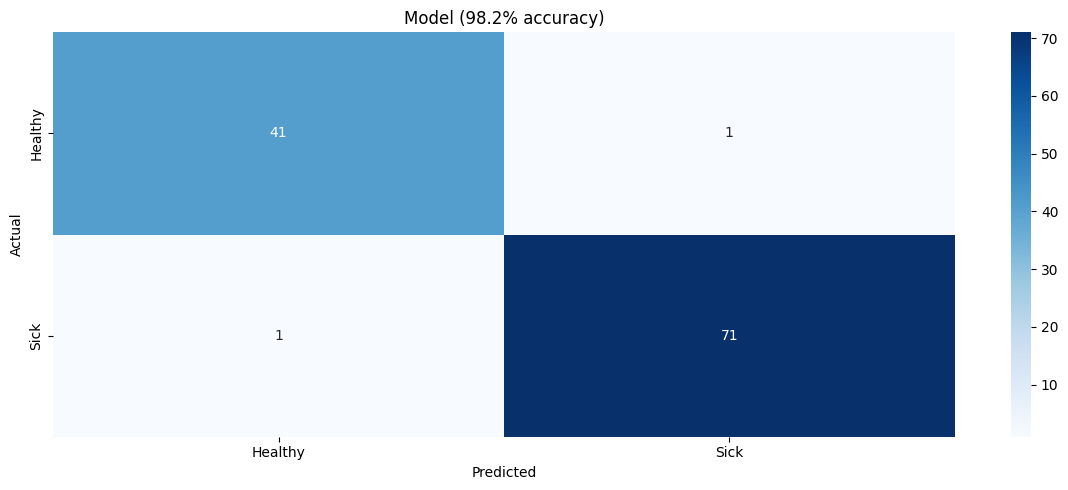

In [50]:
# Step 4: Plot the confusion matrix as a heatmap
# Label axes with cancer.target_names

# YOUR CODE HERE
cm = confusion_matrix(y_test, y_predict)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

sns.heatmap(
    matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Healthy', 'Sick'],
    yticklabels=['Healthy', 'Sick'],
    ax=ax
)

ax.set_title(f'Model ({accuracy:.1%} accuracy)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()


In [51]:
# Step 5: Compute precision, recall, F1 manually from TP/FP/FN
# Then verify with sklearn functions
# Hint: cm.ravel() gives you TN, FP, FN, TP

# YOUR CODE HERE
TN, FP, FN, TP = cm.ravel()
precision_manual = TP / (TP + FP)
recall_manual    = TP / (TP + FN)
f1_manual        = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print('=== Computed by hand ===')
print(f'Precision = TP / (TP + FP) = {TP} / ({TP} + {FP}) = {precision_manual:.3f}')
print(f'Recall    = TP / (TP + FN) = {TP} / ({TP} + {FN}) = {recall_manual:.3f}')
print(f'F1        = 2 × P × R / (P + R)                  = {f1_manual:.3f}')

=== Computed by hand ===
Precision = TP / (TP + FP) = 71 / (71 + 1) = 0.986
Recall    = TP / (TP + FN) = 71 / (71 + 1) = 0.986
F1        = 2 × P × R / (P + R)                  = 0.986


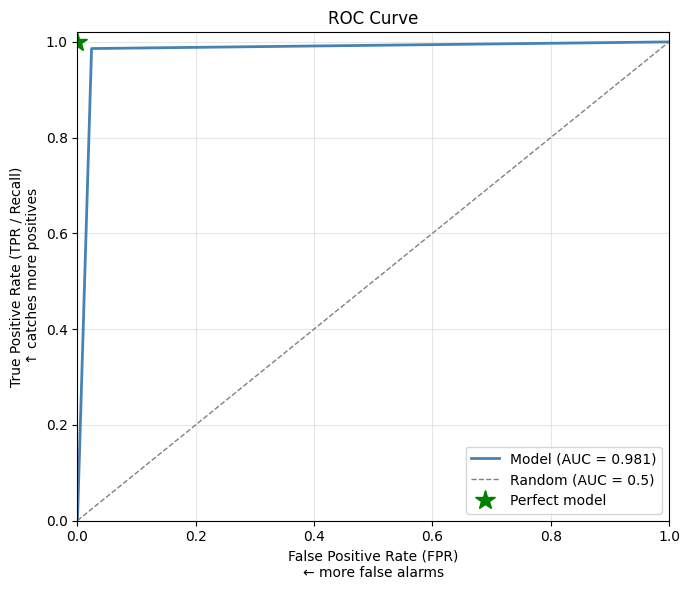

AUC = 0.981

How to read this:
  - Each point on the curve = one threshold setting
  - Top-left corner = perfect (high recall, low false alarm rate)
  - Diagonal = random guessing (useless model)
  - AUC 0.98 means: given a random sick and healthy patient,
    the model ranks the sick one higher 98% of the time


In [52]:
# Step 6: Plot the ROC curve and print the AUC score
# Use model.predict_proba(X_test_s)[:, 1] to get probability scores

# YOUR CODE HERE
fpr, tpr, thresholds_roc = roc_curve(y_test, y_predict)
auc = roc_auc_score(y_test, y_predict)

fig, ax = plt.subplots(figsize=(7, 6))

# Our model's ROC curve
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Model (AUC = {auc:.3f})')

# Random baseline — diagonal line (AUC = 0.5)
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')

# Perfect model point — top-left corner
ax.plot(0, 1, 'g*', markersize=15, label='Perfect model')

ax.set_xlabel('False Positive Rate (FPR)\n← more false alarms')
ax.set_ylabel('True Positive Rate (TPR / Recall)\n↑ catches more positives')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.3f}')
print()
print('How to read this:')
print('  - Each point on the curve = one threshold setting')
print('  - Top-left corner = perfect (high recall, low false alarm rate)')
print('  - Diagonal = random guessing (useless model)')
print(f'  - AUC {auc:.2f} means: given a random sick and healthy patient,')
print(f'    the model ranks the sick one higher {auc:.0%} of the time')

In [53]:
# Step 7: Run 5-fold cross-validation using a Pipeline
# Score on F1. Print mean ± std.

# YOUR CODE HERE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=5000))
])

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

print('5-fold cross-validation F1 scores:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')

print(f'\nMean F1: {cv_scores.mean():.4f}')
print(f'Std:     {cv_scores.std():.4f}  ← how consistent the model is across folds')
print()
print('Report model performance as: mean ± std')
print(f'This model: F1 = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

5-fold cross-validation F1 scores:
  Fold 1: 0.9859
  Fold 2: 0.9861
  Fold 3: 0.9796
  Fold 4: 0.9793
  Fold 5: 0.9929

Mean F1: 0.9848
Std:     0.0050  ← how consistent the model is across folds

Report model performance as: mean ± std
This model: F1 = 0.985 ± 0.005


In [ ]:
# Step 8: Written reflection (answer as comments)

# Q1: This is cancer detection. Should you prioritize precision or recall? Why?
# YOUR ANSWER:

# Q2: Look at the FN count in your confusion matrix.
#     What does each false negative mean in real-world terms?
# YOUR ANSWER:

# Q3: Your cross-validation F1 — is this model good enough to deploy?
#     What other information would you want before deciding?
# YOUR ANSWER:


---
## Extension Challenges (optional)

- **Easy:** Try different thresholds (0.3, 0.4, 0.5, 0.6, 0.7) on the cancer model and see how precision and recall change. Which threshold would you choose for a cancer screening tool?
- **Medium:** Load the Titanic dataset, build a survival classifier, and produce a full evaluation report: confusion matrix, classification report, ROC curve, AUC, and 5-fold cross-validation F1.
- **Hard:** Research `precision_recall_curve` in sklearn. Plot the precision-recall curve (not ROC) for the cancer model. When is the PR curve more informative than the ROC curve?